# Notebook 01 — Exploratory Data Analysis
### **Project:** Customer Support Ticket Classifier & Routing Engine

**Dataset:** Kaggle — Customer Support on Twitter

### **Goal:** Understand the raw data, filter to inbound customer messages, explore text patterns and volume trends.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')

pd.set_option('display.max_colwidth', 120)

## 1. Load Data


In [12]:
df = pd.read_csv('/Applications/Studyyy/Projects/Customer Support Ticket Classifier & Routing Engine/support_classifier/data/raw/twcs.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (2811774, 7)


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist you. We would need to get you into a private secured link to further as...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messages and no one is responding as usual,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so that we can further assist you. Just click ‘Message’ at the top of your ...,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


In [13]:
print('Columns:', df.columns.tolist())
print('\nDtypes:')
print(df.dtypes)
print('\nNull counts:')
print(df.isnull().sum())

Columns: ['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id']

Dtypes:
tweet_id                     int64
author_id                   object
inbound                       bool
created_at                  object
text                        object
response_tweet_id           object
in_response_to_tweet_id    float64
dtype: object

Null counts:
tweet_id                         0
author_id                        0
inbound                          0
created_at                       0
text                             0
response_tweet_id          1040629
in_response_to_tweet_id     794335
dtype: int64


## 2. Filter to Inbound Customer Messages Only
The `inbound` column is True for customer messages, False for company responses. We only want customer tickets.

In [14]:
# Filter inbound = customer messages
customers = df[df['inbound'] == True].copy()
print(f'Total rows: {len(df):,}')
print(f'Inbound (customer) messages: {len(customers):,}')
print(f'Outbound (company) messages: {len(df[df["inbound"] == False]):,}')
customers.head()

Total rows: 2,811,774
Inbound (customer) messages: 1,537,843
Outbound (company) messages: 1,273,931


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messages and no one is responding as usual,1,4.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0
6,8,115712,True,Tue Oct 31 21:45:10 +0000 2017,@sprintcare is the worst customer service,"9,6,10",NaN
8,12,115713,True,Tue Oct 31 22:04:47 +0000 2017,@sprintcare You gonna magically change your connectivity for me and my whole family ? 🤥 💯,"11,13,14",15.0


## 3. Text Length Distribution

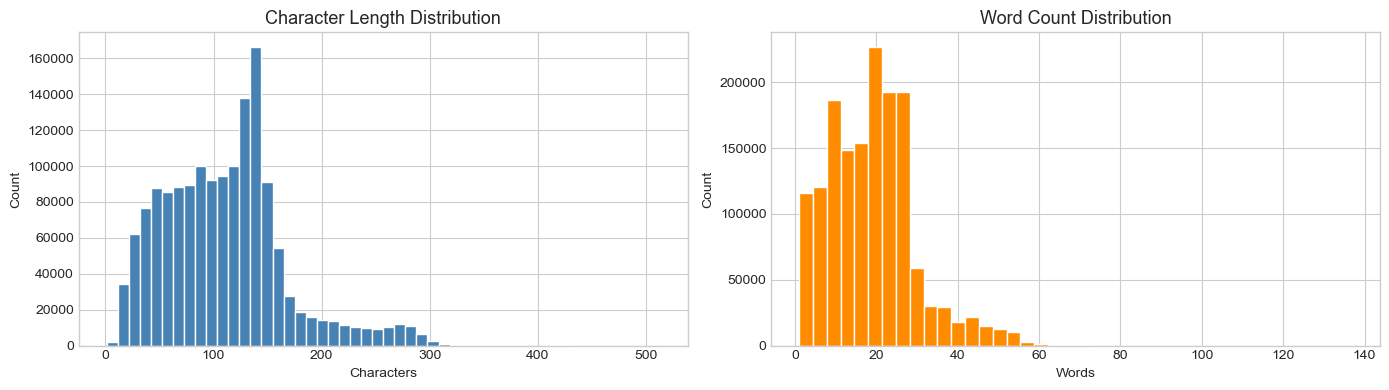

       text_length  word_count
count    1537843.0   1537843.0
mean         109.9        18.7
std           57.2        10.6
min            1.0         1.0
25%           67.0        11.0
50%          109.0        18.0
75%          140.0        25.0
max          513.0       137.0


In [15]:
customers['text_length'] = customers['text'].astype(str).apply(len)
customers['word_count'] = customers['text'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(customers['text_length'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Character Length Distribution', fontsize=13)
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Count')

axes[1].hist(customers['word_count'], bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('Word Count Distribution', fontsize=13)
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Count')

plt.tight_layout()

plt.show()

print(customers[['text_length', 'word_count']].describe().round(1))

## 4. Volume Over Time

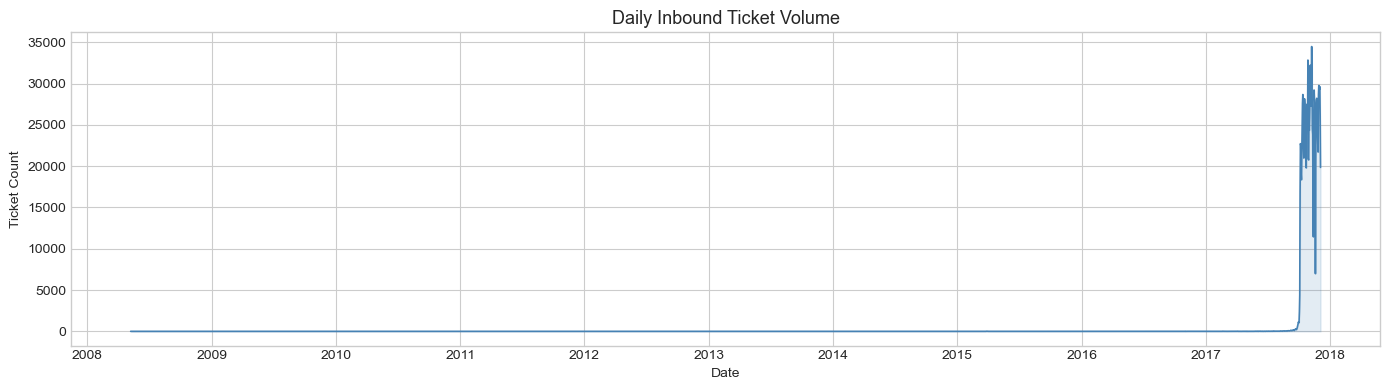

In [16]:
customers['created_at'] = pd.to_datetime(customers['created_at'], errors='coerce')
customers['date'] = customers['created_at'].dt.date
customers['hour'] = customers['created_at'].dt.hour

daily = customers.groupby('date').size().reset_index(name='ticket_count')

plt.figure(figsize=(14, 4))
plt.plot(daily['date'], daily['ticket_count'], color='steelblue', linewidth=1.2)
plt.fill_between(daily['date'], daily['ticket_count'], alpha=0.15, color='steelblue')
plt.title('Daily Inbound Ticket Volume', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Ticket Count')
plt.tight_layout()
plt.show()

## 5. Top Keywords (Raw)
Before cleaning — what words show up most?

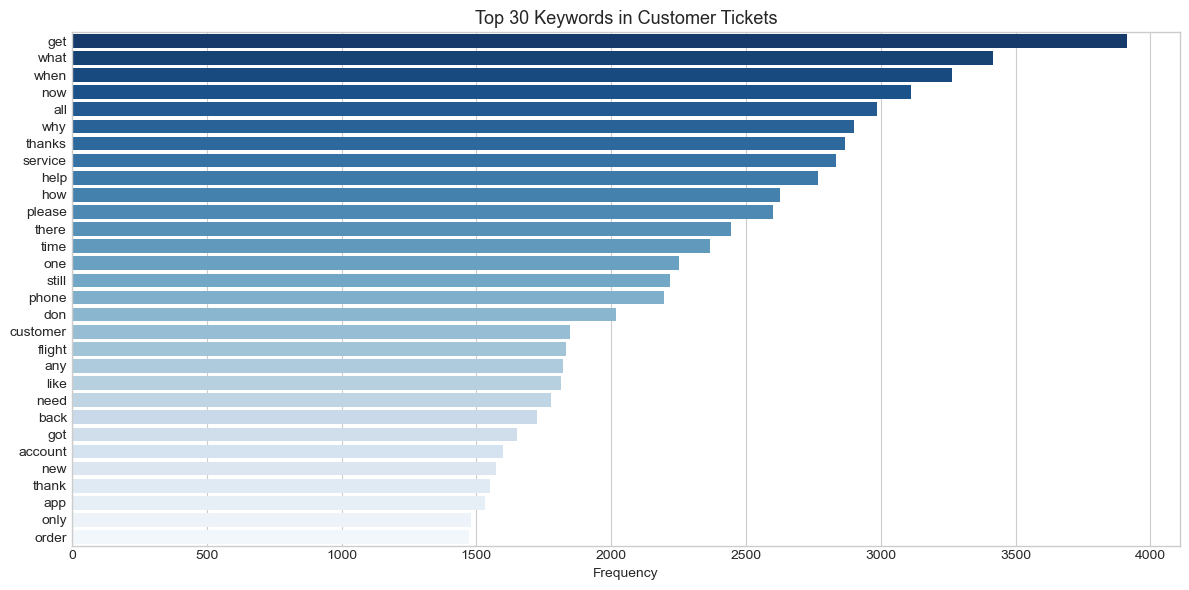

In [17]:
from collections import Counter
import re

STOPWORDS = set([
    'i', 'me', 'my', 'we', 'our', 'you', 'your', 'he', 'she', 'it', 'its',
    'they', 'them', 'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at',
    'to', 'for', 'of', 'with', 'is', 'are', 'was', 'be', 'been', 'have',
    'has', 'had', 'do', 'does', 'did', 'will', 'would', 'can', 'could',
    'not', 'no', 'so', 'if', 'this', 'that', 'by', 'from', 'up', 'out',
    'about', 'into', 'then', 'than', 'just', 'also', 'amp', 'https', 'http'
])

def get_words(text):
    text = re.sub(r'@\w+|http\S+|[^a-z\s]', ' ', str(text).lower())
    return [w for w in text.split() if len(w) > 2 and w not in STOPWORDS]

# Sample 50k for speed
sample = customers['text'].sample(min(50000, len(customers)), random_state=42)
all_words = [w for text in sample for w in get_words(text)]
top_words = Counter(all_words).most_common(30)

words_df = pd.DataFrame(top_words, columns=['word', 'count'])

plt.figure(figsize=(12, 6))
sns.barplot(data=words_df, x='count', y='word', palette='Blues_r')
plt.title('Top 30 Keywords in Customer Tickets', fontsize=13)
plt.xlabel('Frequency')
plt.ylabel('')
plt.tight_layout()

plt.show()

## 6. Sample Tickets
Read a random sample to understand what issue types naturally appear.

In [18]:
print('=== 20 RANDOM CUSTOMER TICKETS ===')
for i, row in customers['text'].sample(20, random_state=1).items():
    print(f'[{i}] {row}')
    print()

=== 20 RANDOM CUSTOMER TICKETS ===
[1178310] @115913 Called cust service &amp; every store in my area. No info on JOD pricing for #iphonex. Please help?

[1980974] @ChipotleTweets It’s okay. I still love you. Ima get a double chicken bowl today for you :)

[717815] @Ask_Spectrum Nah, we'll keep this public. Everyone would benefit from a hard power switch on their converter.

[1781489] I changed my plan to 1 gb everyday on 12th Oct &amp; was told that the same shall be done. But it was not changed and I was charged.@idea_cares

[2537262] @115873 @Uber_Support @15060  I'm looking for some basic info about your IT department for an MBA term group project. Any chance of getting a few short and sweet questions answered?🙏

[693230] @comcastcares I need to cancel my service. Please advise how I can do that.  There is no option in the app.  Thx

[1183413] @115873 your drivers are abusing with your customer when we deny to tell them the drop location, I'm gonna file a case. :(

[1425115] @marks

## 7. Save Filtered Dataset

In [19]:
customers.to_csv('/Applications/Studyyy/Projects/Customer Support Ticket Classifier & Routing Engine/support_classifier/data/processed/inbound_tickets.csv', index=False)
print(f'Saved {len(customers):,} inbound tickets to ../data/processed/inbound_tickets.csv')

Saved 1,537,843 inbound tickets to ../data/processed/inbound_tickets.csv


## EDA Summary
- Full dataset: 2,811,774 tweets from brands including Sprint, Apple, Amazon, 
  Uber, Spotify, Comcast, Tesco, Virgin Trains, HP, and more
- Filtered to inbound=True customer messages: 1,537,843 tickets (54.7% of total)
- Tweets are short — avg ~15 words, well within BERT's 128 token limit
- Top keywords signal 6 natural issue types: technical errors, billing/payment, 
  account access, shipping/delivery, general inquiries, refund/return requests
- Date range: October 2017, single-month snapshot across global brands
- No critical null issues in text or inbound columns
- Next: Notebook 02 — clean text, K-Means clustering to engineer category labels